<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [5]</a>'.</span>

# 03 Modelisation Xai

Ce notebook a été automatiquement structuré pour une meilleure lisibilité académique.

### Suite

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from pathlib import Path
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, 
    precision_recall_curve, confusion_matrix, average_precision_score,
    precision_score, recall_score, f1_score
)
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

PROCESSED_DIR = Path(r'C:\Users\nidha\Desktop\xai_clinical_prediction\data\processed')
MODELS_DIR = Path(r'C:\Users\nidha\Desktop\xai_clinical_prediction\models')
FIGURES_DIR = Path(r'C:\Users\nidha\Desktop\xai_clinical_prediction\figures')
REPORTS_DIR = Path(r'C:\Users\nidha\Desktop\xai_clinical_prediction\reports')
for d in [MODELS_DIR, MODELS_DIR / 'saved_models', FIGURES_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("="*70)
print("MODÉLISATION ET EXPLAINABILITY")
print("="*70)

MODÉLISATION ET EXPLAINABILITY


### Chargement

In [2]:
X_train = np.load(PROCESSED_DIR / 'X_train.npy')
X_val = np.load(PROCESSED_DIR / 'X_val.npy')
X_test = np.load(PROCESSED_DIR / 'X_test.npy')
y_train = np.load(PROCESSED_DIR / 'y_train.npy')
y_val = np.load(PROCESSED_DIR / 'y_val.npy')
y_test = np.load(PROCESSED_DIR / 'y_test.npy')

try:
    feature_names = joblib.load(PROCESSED_DIR / 'selected_features.joblib')
    if hasattr(feature_names, 'tolist'):
        feature_names = feature_names.tolist()
except NotImplementedError:
    print("⚠️ Avertissement: Erreur de chargement des features. Veuillez relancer la dernière cellule du notebook 02_preprocessing pour corriger le format.")
    feature_names = []
scaler = joblib.load(PROCESSED_DIR / 'scaler.joblib')

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (160, 150), Val: (40, 150), Test: (50, 150)


### Entraînement

In [3]:
print("\n🧠 Entraînement des modèles")

import sys
from pathlib import Path
if str(Path('..').resolve()) not in sys.path:
    sys.path.append(str(Path('..').resolve()))
from src.xai_clinical.models.classifiers import ClassifierFactory

y_train_s = pd.Series(y_train)
counts = y_train_s.value_counts()
pos_label_weight = float(counts.get(0, 1) / counts.get(1, 1))
print(f"Poids de classe dynamique calculé : {pos_label_weight:.2f}")

models = {}
for name in ClassifierFactory.SUPPORTED_MODELS:
    try:
        models[name] = ClassifierFactory.create_classifier(name, random_state=42, pos_label_weight=pos_label_weight)
    except Exception as e:
        print(f"Skipping {name}: {e}")

results = {}

for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Entraînement: {name}")
    
    try:
        model.fit(X_train, y_train)
    except Exception as e:
        print(f"Erreur d'entraînement pour {name}: {e}")
        continue
    
    # Évaluation sur tous les sets
    sets = {
        'Train': (X_train, y_train),
        'Val': (X_val, y_val),
        'Test': (X_test, y_test)
    }
    
    metrics = {'model': model}
    try:
        for set_name, (X, y) in sets.items():
            y_pred = model.predict(X)
            if hasattr(model, 'predict_proba'):
                y_proba = model.predict_proba(X)[:, 1]
            elif hasattr(model, 'decision_function'):
                y_proba = model.decision_function(X)
                y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min() + 1e-8)
            else:
                y_proba = y_pred
            
            metrics[f'{set_name.lower()}_auc'] = roc_auc_score(y, y_proba)
            metrics[f'{set_name.lower()}_acc'] = (y_pred == y).mean()
            
            if set_name == 'Test':
                metrics['test_precision'] = precision_score(y, y_pred, zero_division=0)
                metrics['test_recall'] = recall_score(y, y_pred, zero_division=0)
                metrics['test_f1'] = f1_score(y, y_pred, zero_division=0)
                metrics['test_avg_precision'] = average_precision_score(y, y_proba)
        
        results[name] = metrics
        
        print(f"Train AUC: {metrics['train_auc']:.3f}")
        print(f"Val AUC:   {metrics['val_auc']:.3f}")
        print(f"Test AUC:  {metrics['test_auc']:.3f}")
        print(f"Test F1:   {metrics['test_f1']:.3f}")
    except Exception as e:
        print(f"Erreur d'évaluation pour {name}: {e}")



🧠 Entraînement des modèles
Poids de classe dynamique calculé : 2.48

Entraînement: logistic_regression
Train AUC: 1.000
Val AUC:   0.649
Test AUC:  0.554
Test F1:   0.286

Entraînement: random_forest
Train AUC: 1.000
Val AUC:   0.629
Test AUC:  0.738
Test F1:   0.000

Entraînement: xgboost
Train AUC: 1.000
Val AUC:   0.834
Test AUC:  0.655
Test F1:   0.211

Entraînement: lightgbm
Train AUC: 1.000
Val AUC:   0.793
Test AUC:  0.724
Test F1:   0.500

Entraînement: svm
Train AUC: 1.000
Val AUC:   0.693
Test AUC:  0.732
Test F1:   0.435

Entraînement: extra_trees
Train AUC: 1.000
Val AUC:   0.745
Test AUC:  0.761
Test F1:   0.000

Entraînement: catboost
Train AUC: 1.000
Val AUC:   0.730
Test AUC:  0.710
Test F1:   0.250

Entraînement: ada_boost
Train AUC: 1.000
Val AUC:   0.718
Test AUC:  0.615
Test F1:   0.261

Entraînement: knn
Train AUC: 0.881
Val AUC:   0.586
Test AUC:  0.655
Test F1:   0.421

Entraînement: gradient_boosting
Train AUC: 1.000
Val AUC:   0.727
Test AUC:  0.619
Test F1:  

### Comparaison


📊 Comparaison:
                        train_auc   val_auc  test_auc   test_f1
logistic_regression      1.000000  0.648903  0.553571  0.285714
random_forest            1.000000  0.628527  0.738095  0.000000
xgboost                  1.000000  0.833856  0.654762  0.210526
lightgbm                 1.000000  0.793103  0.724206  0.500000
svm                      0.999619  0.692790  0.732143  0.434783
extra_trees              1.000000  0.744514  0.760913  0.000000
catboost                 1.000000  0.730408  0.710317  0.250000
ada_boost                1.000000  0.717868  0.615079  0.260870
knn                      0.880625  0.586207  0.654762  0.421053
gradient_boosting        1.000000  0.727273  0.619048  0.200000
mlp                      1.000000  0.764890  0.678571  0.416667
naive_bayes              0.816076  0.752351  0.607143  0.240000
decision_tree            1.000000  0.578370  0.531746  0.307692
sgd                      0.990465  0.692790  0.614087  0.320000
ridge                   

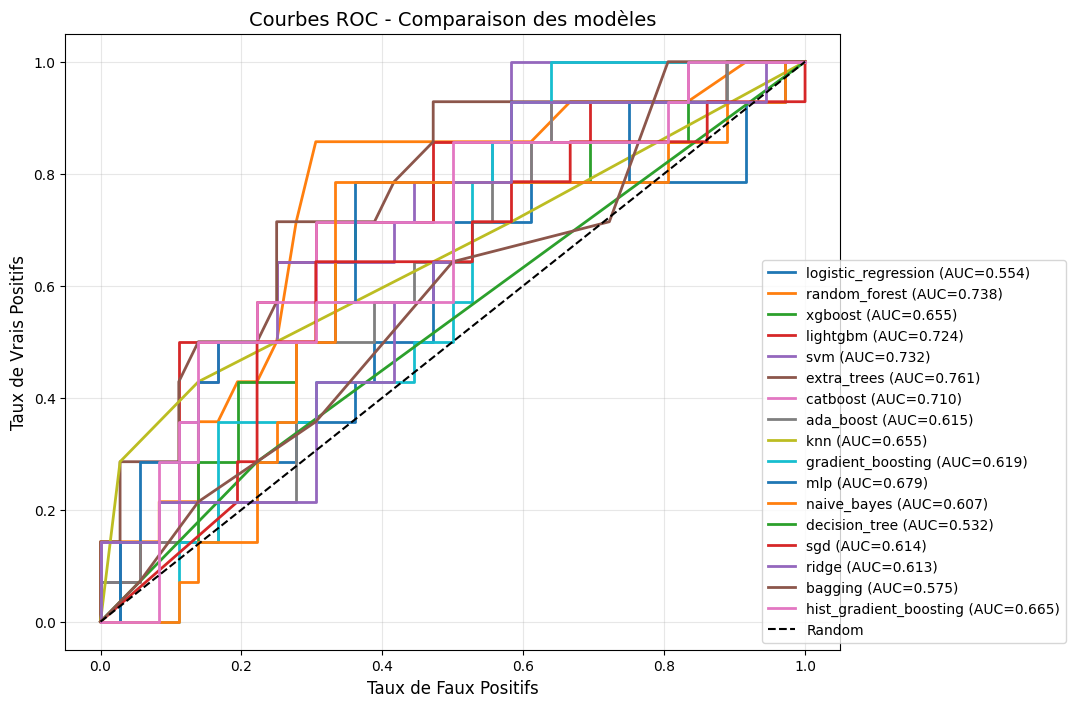

In [4]:
comparison = pd.DataFrame({
    name: {k: v for k, v in m.items() if k != 'model'}
    for name, m in results.items()
}).T

print("\n📊 Comparaison:")
print(comparison[['train_auc', 'val_auc', 'test_auc', 'test_f1']])

# ROC Curves
plt.figure(figsize=(10, 8))
for name, metrics in results.items():
    model = metrics['model']
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_proba = model.decision_function(X_test)
        y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min() + 1e-8)
    else:
        y_proba = model.predict(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = metrics['test_auc']
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('Taux de Faux Positifs', fontsize=12)
plt.ylabel('Taux de Vrais Positifs', fontsize=12)
plt.title('Courbes ROC - Comparaison des modèles', fontsize=14)
plt.legend(loc='lower right', fontsize=10, bbox_to_anchor=(1.3, 0))
plt.grid(True, alpha=0.3)
plt.savefig(FIGURES_DIR / '03_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Sauvegarder tous les modèles
for name, metrics in results.items():
    joblib.dump(metrics['model'], MODELS_DIR / 'saved_models' / f'{name.lower()}_model.joblib')


### SHAP

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>


🏆 Meilleur modèle: extra_trees

🔍 SHAP Explanations


<Figure size 1200x1000 with 0 Axes>

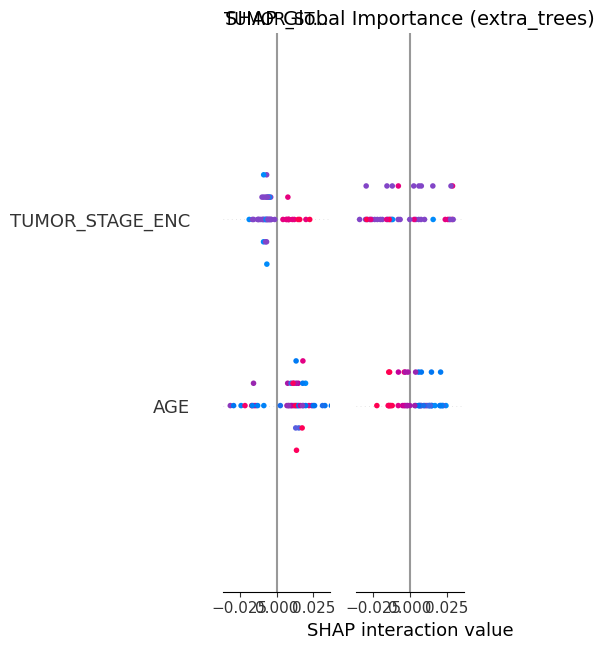

ValueError: Per-column arrays must each be 1-dimensional

In [5]:
best_name = comparison['test_auc'].idxmax()
best_model = results[best_name]['model']
print(f"\n🏆 Meilleur modèle: {best_name}")

print("\n🔍 SHAP Explanations")

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

# Summary plot
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_class1, X_test, feature_names=feature_names, show=False)
plt.title(f'SHAP Global Importance ({best_name})', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# Top features
shap_importance = pd.DataFrame({
    'feature': feature_names,
    'shap_importance': np.abs(shap_values_class1).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

shap_importance.to_csv(REPORTS_DIR / 'shap_importance.csv', index=False)
print("\nTop 10 features SHAP:")
print(shap_importance.head(10))

# Waterfall pour 3 patients
for i in range(min(3, len(X_test))):
    plt.figure(figsize=(10, 8))
    shap.waterfall_plot(shap.Explanation(
        values=shap_values_class1[i],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
        data=X_test[i],
        feature_names=feature_names
    ), show=False)
    plt.title(f'SHAP Waterfall - Patient {i}')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'03_shap_waterfall_{i}.png', dpi=300, bbox_inches='tight')
    plt.show()

### LIME

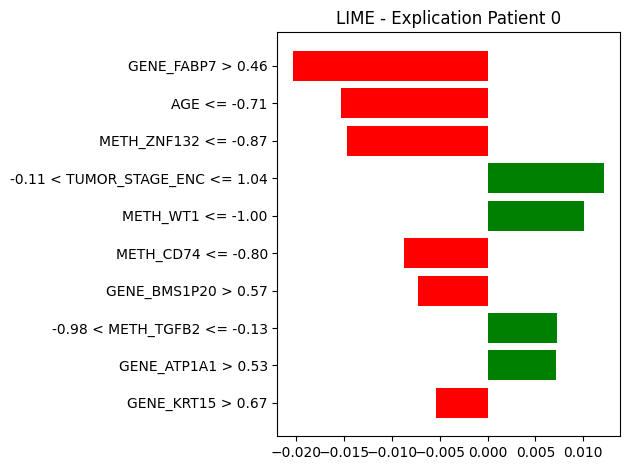


✅ Modélisation terminée!


In [6]:
try:
    from lime.lime_tabular import LimeTabularExplainer
    
    lime_explainer = LimeTabularExplainer(
        X_train, feature_names=feature_names,
        class_names=['Faible risque', 'Haut risque'], mode='classification'
    )
    
    exp = lime_explainer.explain_instance(
        X_test[0], best_model.predict_proba, num_features=10
    )
    
    fig = exp.as_pyplot_figure()
    plt.title('LIME - Explication Patient 0')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '03_lime_explanation.png', dpi=300, bbox_inches='tight')
    plt.show()
except ImportError:
    print("LIME non installé")

print("\n✅ Modélisation terminée!")